# P1: ThermoML Dielectric Data Probe

Inspect the provisional live NIST API fallback census produced by
`probes/p1_thermoml_dielectric.py`. The complete 2020 archive was unavailable,
so the handbook gate was not formally executed. The gate uses the 100 unique
pure-component zero-frequency compounds near 298 K; mixture partners remain
in the separate all-component census.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

repository_root = Path.cwd()
while not (repository_root / "pyproject.toml").is_file():
    repository_root = repository_root.parent
summary_path = repository_root / "probes" / "p1_summary.json"
observations_path = repository_root / "data" / "processed" / "dielectric_raw.csv"

summary = json.loads(summary_path.read_text(encoding="utf-8"))
observations = pd.read_csv(observations_path)

print(json.dumps(summary, ensure_ascii=False, indent=2))
print("\nRows:", len(observations))
print("Columns:", ", ".join(observations.columns))

{
  "observation_rows": 11646,
  "source_documents_with_dielectric_rows": 91,
  "property_family_counts": {
    "frequency_dependent": 5303,
    "zero_frequency": 6343
  },
  "temperature_center_k": "298.15",
  "temperature_tolerance_k": "5",
  "observations_near_center": 5690,
  "unique_components_near_center": 178,
  "all_component_zero_frequency_components_near_center": 124,
  "zero_frequency_observations_near_center": 2810,
  "unique_zero_frequency_components_near_center": 124,
  "pure_zero_frequency_components_near_center": 100,
  "component_observation_family_counts": {
    "carbonate": 230,
    "ether": 1304,
    "nitrile": 260,
    "other": 18484,
    "sulfone": 798
  },
  "unique_component_family_counts": {
    "carbonate": 2,
    "ether": 8,
    "nitrile": 6,
    "other": 166,
    "sulfone": 2
  },
  "zero_frequency_family_counts_near_center": {
    "carbonate": 2,
    "ether": 3,
    "nitrile": 4,
    "other": 113,
    "sulfone": 2
  },
  "pure_zero_frequency_family_counts_n

In [2]:
observations.groupby("property_family").agg(
    observations=("value", "size"),
    compounds=("primary_inchi_key", "nunique"),
    median_value=("value", "median"),
)

,observations,compounds,median_value
property_family,,,
frequency_dependent,5303,97,9.35
zero_frequency,6343,118,17.63


dielectric_distribution.png


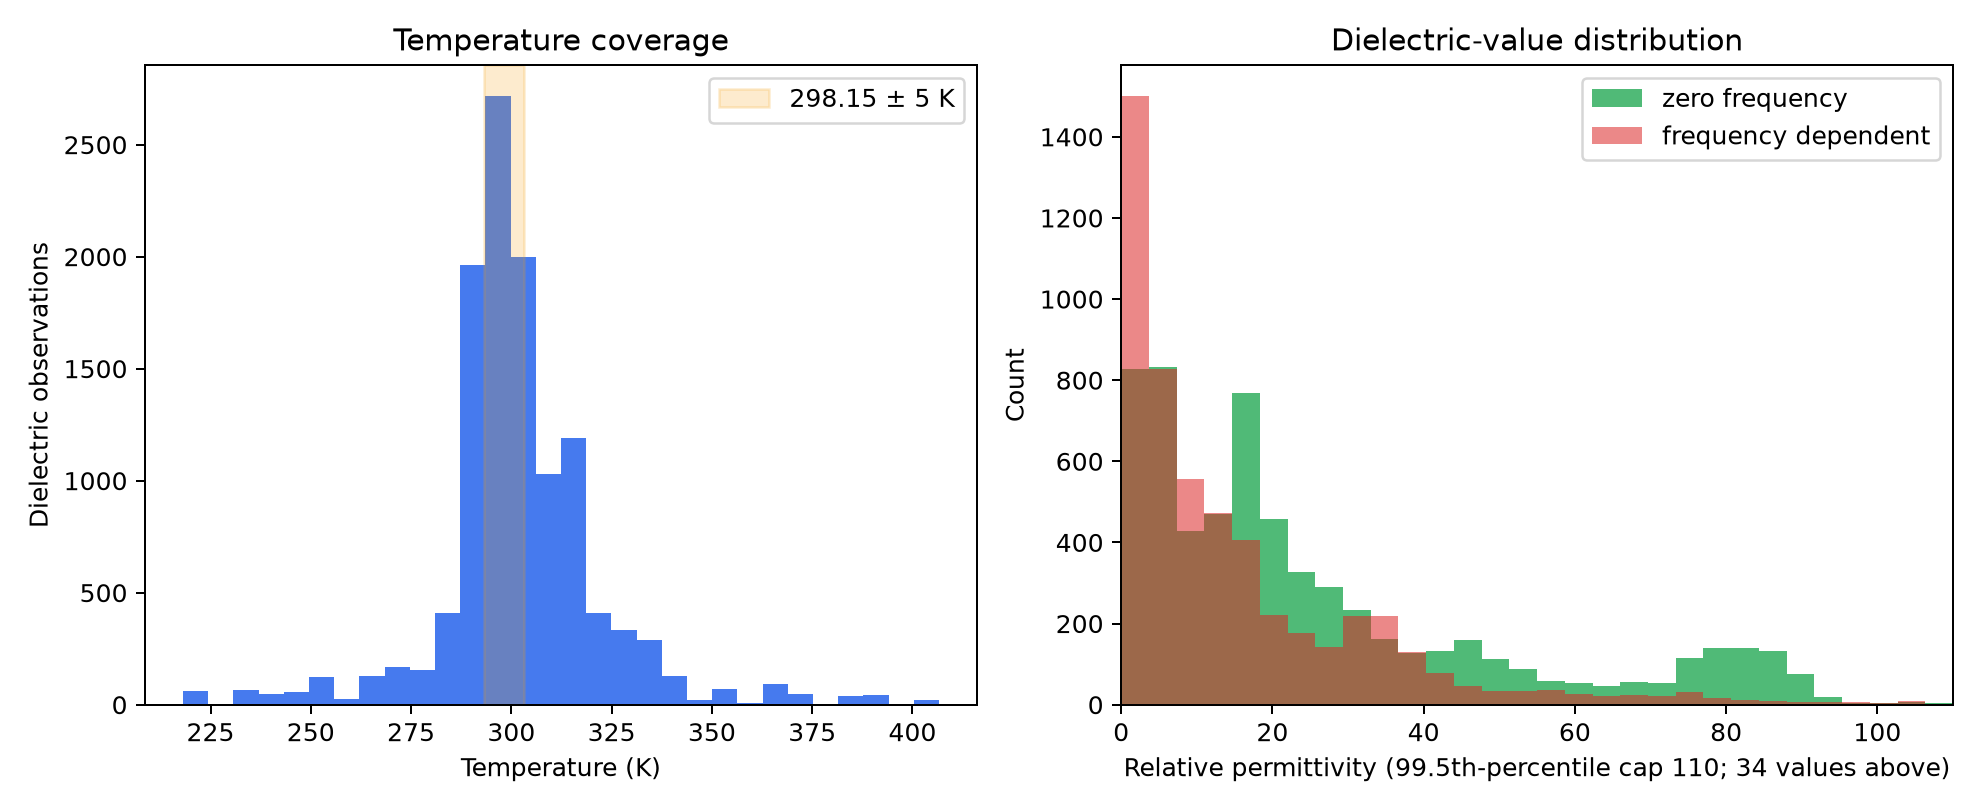

family_coverage.png


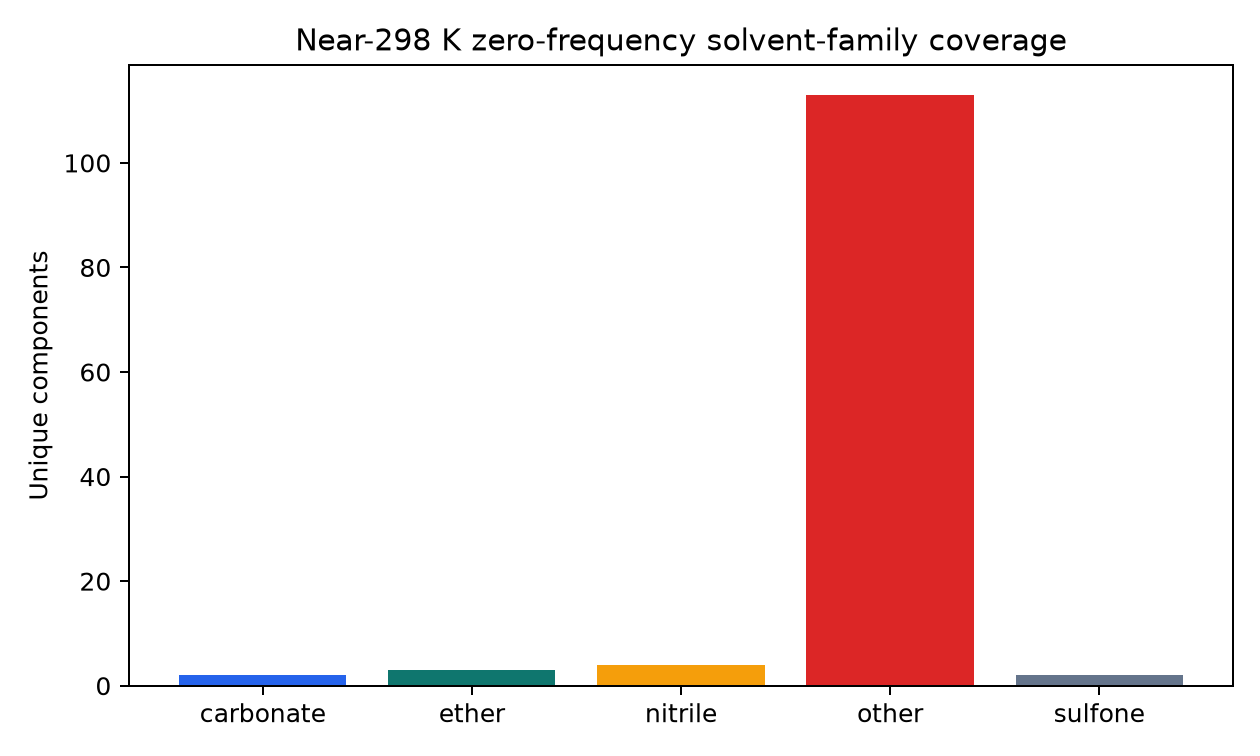

In [3]:
artifacts = [Path(path) for path in summary["outputs"].values() if path.endswith(".png")]
for path in artifacts:
    print(path.name)
    display(Image(filename=str(path)))